# CE310 Part 2 - Genetic Programming (Final Submission Version)

This notebook follows the same incremental pattern: explain the step, run code, inspect evidence.

## Environment Setup
Load modules and detect the project root robustly across different working folders.

In [1]:
from pathlib import Path
import sys
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

ROOT = Path('.').resolve()
PROJECT_ROOT = next((p for p in [ROOT, *ROOT.parents] if (p / 'ce310').exists()), ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ce310.gp import (
    PRIMITIVE_NAME_BY_CODE,
    decode_program_population,
    execute,
    make_gp_fitness_function,
)

R2 = PROJECT_ROOT / 'results' / 'part2'
FIG = PROJECT_ROOT / 'figures'
print('PROJECT_ROOT =', PROJECT_ROOT)
print('Part2 results folder exists:', R2.exists())

PROJECT_ROOT = E:\CE310
Part2 results folder exists: True


## Code Completeness Snapshot
Show core interpreter and fitness-construction code for completeness review.

In [2]:
import ce310.gp as gp_mod
print(inspect.getsource(gp_mod.execute)[:1600])
print('\n---\n')
print(inspect.getsource(gp_mod.make_gp_fitness_function)[:2200])

def execute(program: np.ndarray, x: float) -> float:
    stack = []

    def pop() -> float:
        if not stack:
            return 0.0
        return float(stack.pop())

    for instr in program:
        if instr == 0:  # NOP
            pass
        elif instr == 1:  # X
            stack.append(float(x))
        elif instr == 2:  # +
            stack.append(pop() + pop())
        elif instr == 3:  # -
            stack.append(pop() - pop())
        elif instr == 4:  # *
            stack.append(pop() * pop())
        elif instr == 5:  # 1
            stack.append(1.0)
        elif instr == 6:  # -1
            stack.append(-1.0)
        else:  # 0
            stack.append(0.0)

    return pop()


---

def make_gp_fitness_function(
    program_length: int, encoding: GPEncoding, problem: GPProblem
):
    x_values = np.linspace(-1.0, 1.0, 21)
    y_targets = np.array([polynomial_target(float(x)) for x in x_values], dtype=float)
    n_cases = 2 if problem == "problem1" else len(x_val

## Task 5 Step 1 - Primitive Set Verification
Check instruction encoding mapping used by GP.

In [3]:
PRIMITIVE_NAME_BY_CODE

{0: 'NOP', 1: 'X', 2: '+', 3: '-', 4: '*', 5: '1', 6: '-1', 7: '0'}

## Task 5 Step 2 - Program Decoding Test
Validate 3-bit decoding from binary chromosome to instruction sequence.

In [4]:
chrom = np.array([[1,0,1,1,1,1,0,0,0]], dtype=np.int8)  # expected [5,7,0]
decode_program_population(chrom, program_length=3, encoding='3bit')

array([[5, 7, 0]], dtype=int16)

## Task 6 Step 1 - Interpreter Example from Coursework
Verify required example execute([5,1,2],3)=4.

In [5]:
execute(np.array([5,1,2], dtype=np.int16), 3.0)

4.0

## Task 6 Step 2 - Fitness Function Smoke Test
Evaluate both GP problems on random individuals.

In [6]:
rng = np.random.default_rng(123)
dummy = rng.integers(0,2,size=(5,90),dtype=np.int8)
f1 = make_gp_fitness_function(30, '3bit', 'problem1')
f2 = make_gp_fitness_function(30, '3bit', 'problem2')
fit1, meta1 = f1(dummy)
fit2, meta2 = f2(dummy)
fit1, meta1, fit2[:3], meta2

(array([ 0.,  2.,  0.,  0., -2.]),
 {'execute_calls': 10.0,
  'execute_calls_nominal': 10.0,
  'fitness_cases': 2.0,
  'unique_programs': 5.0,
  'duplicate_ratio': 0.0},
 array([-156.28176, -149.43728, -159.83728]),
 {'execute_calls': 105.0,
  'execute_calls_nominal': 105.0,
  'fitness_cases': 21.0,
  'unique_programs': 5.0,
  'duplicate_ratio': 0.0})

## Task 5 Result Summary - Encoding Comparison
Load 3-bit vs 7-bit comparison results.

In [7]:
enc = pd.read_csv(R2 / 'task5_encoding_comparison' / 'encoding_comparison_summary.csv'); enc

,condition,encoding,problem,n_runs,best_of_run_mean,best_of_run_std,final_best_mean,final_best_std,mean_execute_calls_per_generation,mean_execute_calls_nominal_per_generation,execute_call_reduction_ratio,mean_duplicate_ratio_per_generation,ideal_found_fraction,first_ideal_generation_mean
0,3bit_problem1,3bit,problem1,5,32.000000,11.575837,31.200000,11.009087,476.172549,600.0,0.206379,0.206379,NaN,NaN
1,7bit_problem1,7bit,problem1,5,42.400000,15.059880,42.400000,15.059880,415.215686,600.0,0.307974,0.307974,NaN,NaN
2,3bit_problem2,3bit,problem2,5,-70.369216,14.566620,-70.369216,14.566620,4342.552941,6300.0,0.310706,0.310706,0.0,NaN
3,7bit_problem2,7bit,problem2,5,-64.795208,30.703052,-64.795208,30.703052,4888.800000,6300.0,0.224000,0.224000,0.0,NaN


## Task 7 Step 1 - Load Full Experiment Matrix
Inspect all 18 conditions (problem x pop x tournament).

In [8]:
task7 = pd.read_csv(R2 / 'task7_experiments' / 'task7_summary.csv'); task7

,condition,problem,encoding,pop_size,tournament_size,n_runs,best_of_run_mean,best_of_run_std,final_best_mean,final_best_std,mean_execute_calls_per_generation,mean_execute_calls_nominal_per_generation,execute_call_reduction_ratio,mean_duplicate_ratio_per_generation,ideal_found_fraction,first_ideal_generation_mean
0,problem1_3bit_pop50_t2,problem1,3bit,50,2,10,14.200000,9.681598,12.400000,9.276014,60.729412,100.0,0.392706,0.392706,NaN,NaN
1,problem1_3bit_pop50_t3,problem1,3bit,50,3,10,13.400000,3.893014,13.400000,3.893014,45.145098,100.0,0.548549,0.548549,NaN,NaN
2,problem1_3bit_pop50_t5,problem1,3bit,50,5,10,12.400000,6.915361,12.200000,6.696599,40.392157,100.0,0.596078,0.596078,NaN,NaN
3,problem1_3bit_pop100_t2,problem1,3bit,100,2,10,14.200000,6.892830,13.600000,6.979335,145.215686,200.0,0.273922,0.273922,NaN,NaN
4,problem1_3bit_pop100_t3,problem1,3bit,100,3,10,19.400000,16.249444,19.200000,16.362559,102.811765,200.0,0.485941,0.485941,NaN,NaN
5,problem1_3bit_pop100_t5,problem1,3bit,100,5,10,16.200000,7.627436,16.200000,7.627436,79.925490,200.0,0.600373,0.600373,NaN,NaN
6,problem1_3bit_pop200_t2,problem1,3bit,200,2,10,23.000000,9.486833,22.000000,9.285592,295.682353,400.0,0.260794,0.260794,NaN,NaN
7,problem1_3bit_pop200_t3,problem1,3bit,200,3,10,34.400000,21.762353,33.800000,22.399405,195.533333,400.0,0.511167,0.511167,NaN,NaN
8,problem1_3bit_pop200_t5,problem1,3bit,200,5,10,35.800000,17.344868,35.800000,17.344868,107.745098,400.0,0.730637,0.730637,NaN,NaN
9,problem2_3bit_pop50_t2,problem2,3bit,50,2,10,-122.933592,19.534066,-127.267380,17.864069,819.535294,1050.0,0.219490,0.219490,0.0,NaN


## Task 7 Step 2 - Protocol Compliance Check
Confirm the hard requirement: at least 10 independent runs per condition.

In [9]:
ok = bool((task7['n_runs'] >= 10).all())
print('All conditions have at least 10 runs:', ok)
print('Minimum n_runs:', int(task7['n_runs'].min()))
assert ok, 'Some conditions have fewer than 10 runs.'
task7[['condition','n_runs']].head()

All conditions have at least 10 runs: True
Minimum n_runs: 10


,condition,n_runs
0,problem1_3bit_pop50_t2,10
1,problem1_3bit_pop50_t3,10
2,problem1_3bit_pop50_t5,10
3,problem1_3bit_pop100_t2,10
4,problem1_3bit_pop100_t3,10


## Task 7 Step 2b - Ideal Solution Reporting Columns
Explicitly inspect ideal-hit and first-hit-generation statistics.

In [10]:
cols = ['condition','problem','ideal_found_fraction','first_ideal_generation_mean']
task7[cols]

,condition,problem,ideal_found_fraction,first_ideal_generation_mean
0,problem1_3bit_pop50_t2,problem1,NaN,NaN
1,problem1_3bit_pop50_t3,problem1,NaN,NaN
2,problem1_3bit_pop50_t5,problem1,NaN,NaN
3,problem1_3bit_pop100_t2,problem1,NaN,NaN
4,problem1_3bit_pop100_t3,problem1,NaN,NaN
5,problem1_3bit_pop100_t5,problem1,NaN,NaN
6,problem1_3bit_pop200_t2,problem1,NaN,NaN
7,problem1_3bit_pop200_t3,problem1,NaN,NaN
8,problem1_3bit_pop200_t5,problem1,NaN,NaN
9,problem2_3bit_pop50_t2,problem2,0.0,NaN


## Task 7 Step 3 - Parameter Effect Visualization (Problem 1)
Plot mean best-of-run against population size for different tournament sizes.

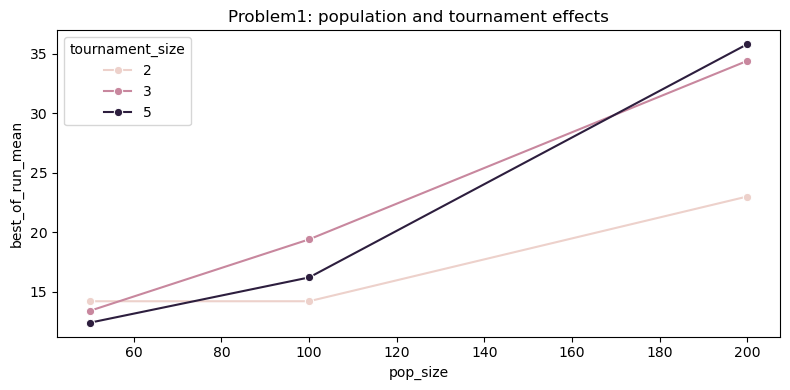

In [11]:
p1 = task7[task7['problem']=='problem1'].copy()
plt.figure(figsize=(8,4))
sns.lineplot(data=p1, x='pop_size', y='best_of_run_mean', hue='tournament_size', marker='o')
plt.title('Problem1: population and tournament effects')
plt.tight_layout()

## Task 7 Step 4 - Parameter Effect Visualization (Problem 2)
Plot mean best-of-run for symbolic regression problem.

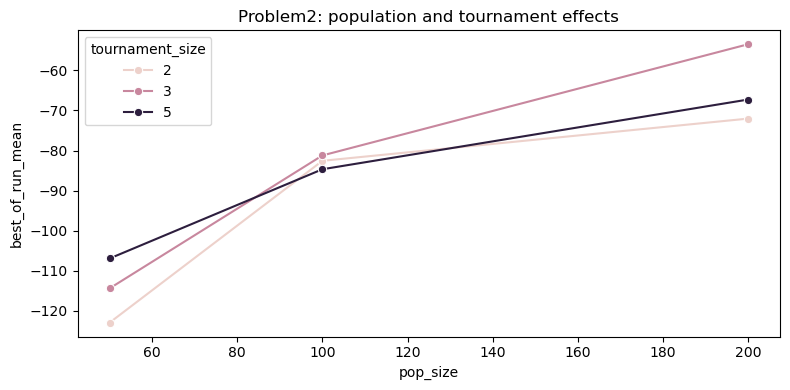

In [12]:
p2 = task7[task7['problem']=='problem2'].copy()
plt.figure(figsize=(8,4))
sns.lineplot(data=p2, x='pop_size', y='best_of_run_mean', hue='tournament_size', marker='o')
plt.title('Problem2: population and tournament effects')
plt.tight_layout()

## Task 7 Step 4b - Enhanced Parameter and Cost Visualizations (if available)
Show prepared heatmap and computational cost figures.

E:\CE310\figures\part2_parameter_impact_heatmap.png


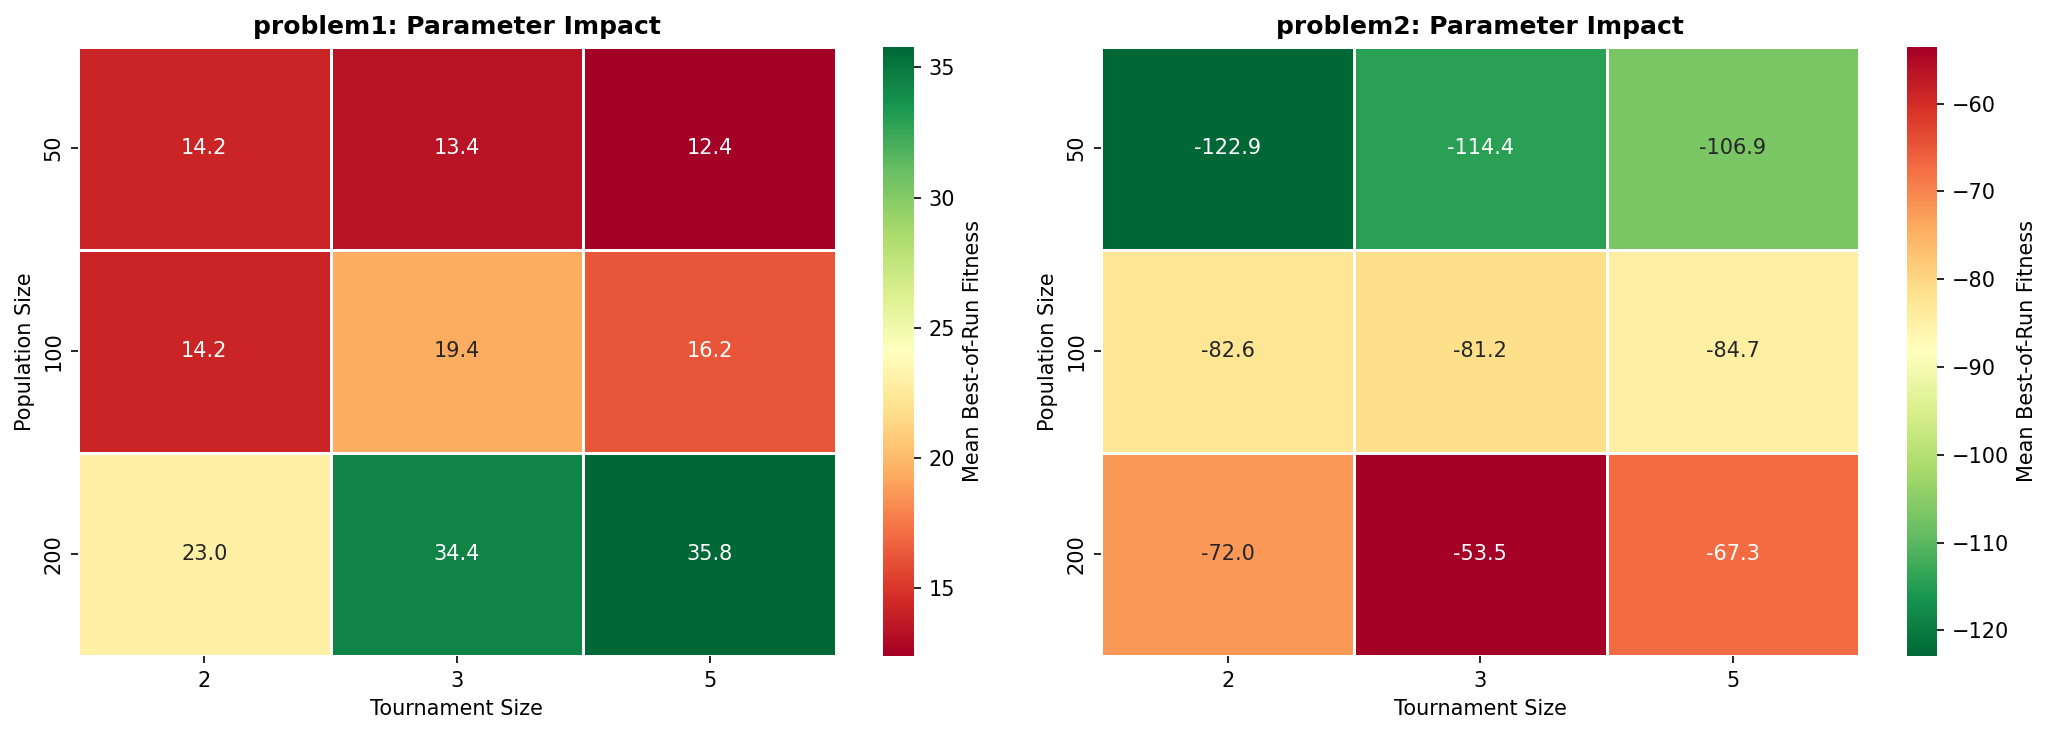

E:\CE310\figures\part2_computational_cost.png


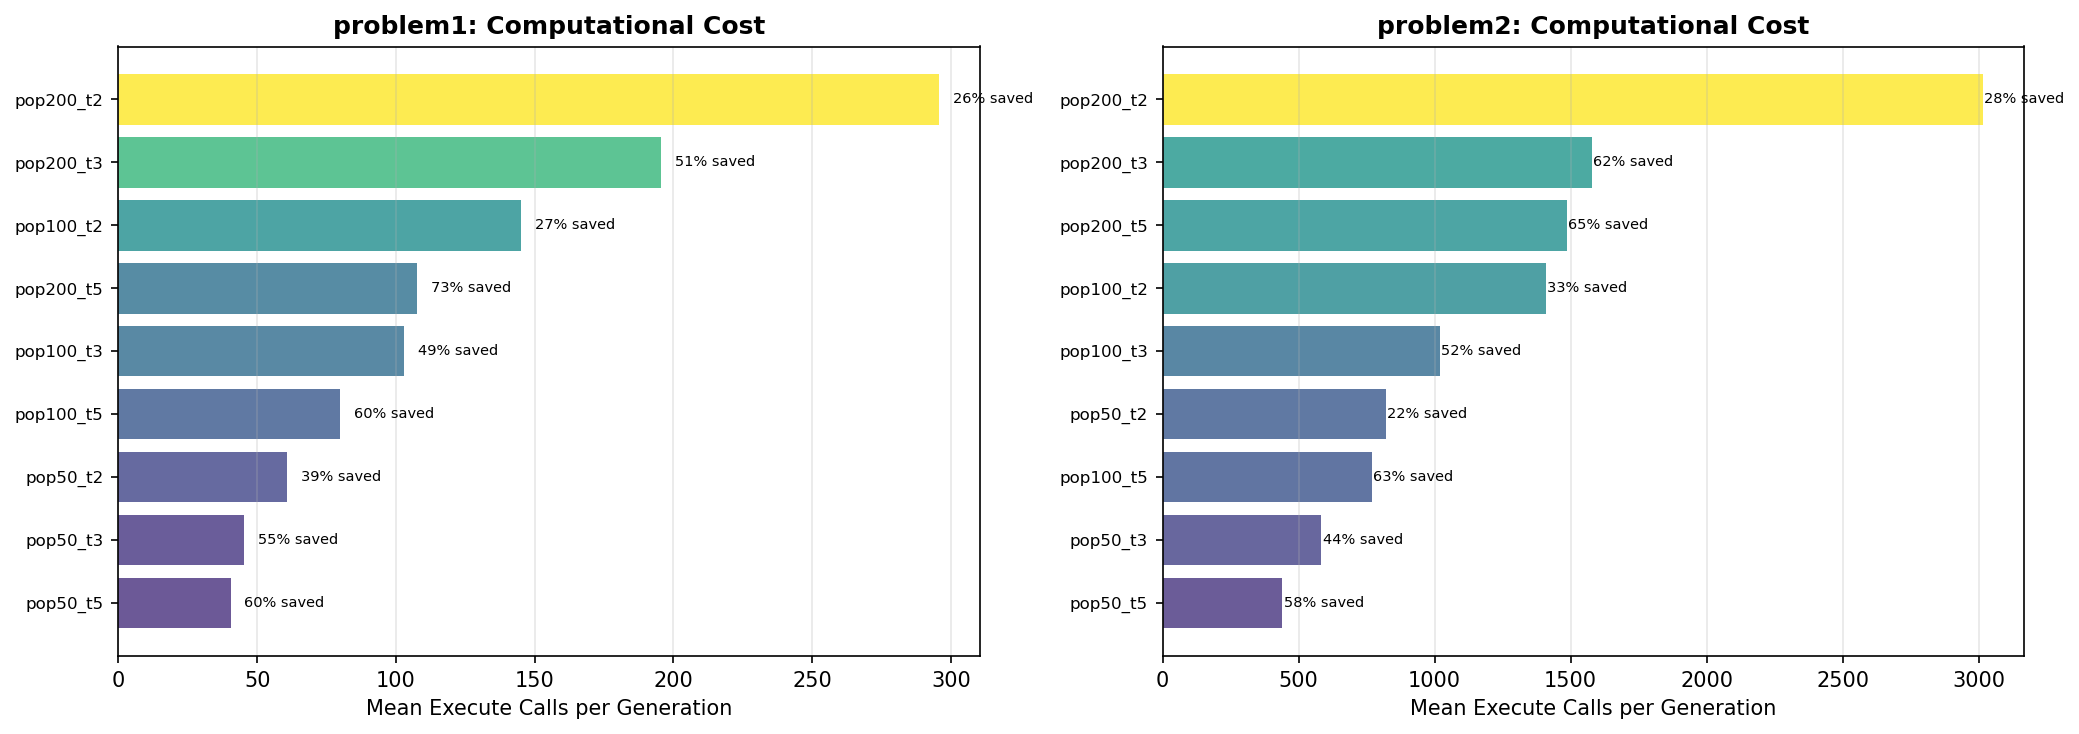

In [13]:
for fn in ['part2_parameter_impact_heatmap.png','part2_computational_cost.png']:
    p = FIG / fn
    print(p)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print('Missing figure:', p)

## Task 7 Step 5 - Computational Effort Analysis
Summarize execute-call statistics and reduction ratio.

In [14]:
cols = ['condition','mean_execute_calls_per_generation','mean_execute_calls_nominal_per_generation','execute_call_reduction_ratio']
task7[cols].sort_values('execute_call_reduction_ratio', ascending=False).head(10)

,condition,mean_execute_calls_per_generation,mean_execute_calls_nominal_per_generation,execute_call_reduction_ratio
8,problem1_3bit_pop200_t5,107.745098,400.0,0.730637
17,problem2_3bit_pop200_t5,1486.964706,4200.0,0.645961
14,problem2_3bit_pop100_t5,767.982353,2100.0,0.634294
16,problem2_3bit_pop200_t3,1578.129412,4200.0,0.624255
5,problem1_3bit_pop100_t5,79.925490,200.0,0.600373
2,problem1_3bit_pop50_t5,40.392157,100.0,0.596078
11,problem2_3bit_pop50_t5,440.711765,1050.0,0.580275
1,problem1_3bit_pop50_t3,45.145098,100.0,0.548549
13,problem2_3bit_pop100_t3,1018.252941,2100.0,0.515118
7,problem1_3bit_pop200_t3,195.533333,400.0,0.511167


## Task 7 Step 5b - Selection Pressure and Variability Diagnostics
I report std and CV with the mean because GP variance is high; this avoids over-claiming small differences.

In [15]:
diag = task7.copy()
diag['cv_best'] = diag['best_of_run_std'] / diag['best_of_run_mean'].abs().replace(0, np.nan)
diag_view = diag[['condition','problem','pop_size','tournament_size','best_of_run_mean','best_of_run_std','cv_best']]
diag_view = diag_view.sort_values(['problem','best_of_run_mean'], ascending=[True, False])
print('Top rows for variability diagnostics:')
diag_view.head(12)

Top rows for variability diagnostics:


,condition,problem,pop_size,tournament_size,best_of_run_mean,best_of_run_std,cv_best
8,problem1_3bit_pop200_t5,problem1,200,5,35.800000,17.344868,0.484494
7,problem1_3bit_pop200_t3,problem1,200,3,34.400000,21.762353,0.632627
6,problem1_3bit_pop200_t2,problem1,200,2,23.000000,9.486833,0.412471
4,problem1_3bit_pop100_t3,problem1,100,3,19.400000,16.249444,0.837600
5,problem1_3bit_pop100_t5,problem1,100,5,16.200000,7.627436,0.470829
0,problem1_3bit_pop50_t2,problem1,50,2,14.200000,9.681598,0.681803
3,problem1_3bit_pop100_t2,problem1,100,2,14.200000,6.892830,0.485411
1,problem1_3bit_pop50_t3,problem1,50,3,13.400000,3.893014,0.290523
2,problem1_3bit_pop50_t5,problem1,50,5,12.400000,6.915361,0.557690
16,problem2_3bit_pop200_t3,problem2,200,3,-53.485068,24.744100,0.462636


## Task 7 Step 6 - Best Conditions and Variability
Identify best settings for each problem and inspect standard deviation.

In [16]:
best_p1 = p1.sort_values('best_of_run_mean', ascending=False).iloc[0]
best_p2 = p2.sort_values('best_of_run_mean', ascending=False).iloc[0]
best_p1[['condition','best_of_run_mean','best_of_run_std']], best_p2[['condition','best_of_run_mean','best_of_run_std','ideal_found_fraction']]

(condition           problem1_3bit_pop200_t5
 best_of_run_mean                       35.8
 best_of_run_std                   17.344868
 Name: 8, dtype: object,
 condition               problem2_3bit_pop200_t3
 best_of_run_mean                     -53.485068
 best_of_run_std                         24.7441
 ideal_found_fraction                        0.0
 Name: 16, dtype: object)

## Task 8 Step 1 - Selected Primitive Trend Conditions
Load selected conditions for primitive analysis.

In [17]:
task8 = pd.read_csv(R2 / 'task8_primitives' / 'task8_selected_conditions.csv'); task8

,problem,selected_condition,best_of_run_mean,best_of_run_std,plot_file
0,problem1,problem1_3bit_pop200_t5,35.800000,17.344868,results\part2\task8_primitives\problem1_primit...
1,problem2,problem2_3bit_pop200_t3,-53.485068,24.744100,results\part2\task8_primitives\problem2_primit...


## Task 8 Step 2 - Display Primitive Trend Plots
Show primitive frequency evolution plots for the selected conditions.

problem1 -> E:\CE310\results\part2\task8_primitives\problem1_primitive_trends.png


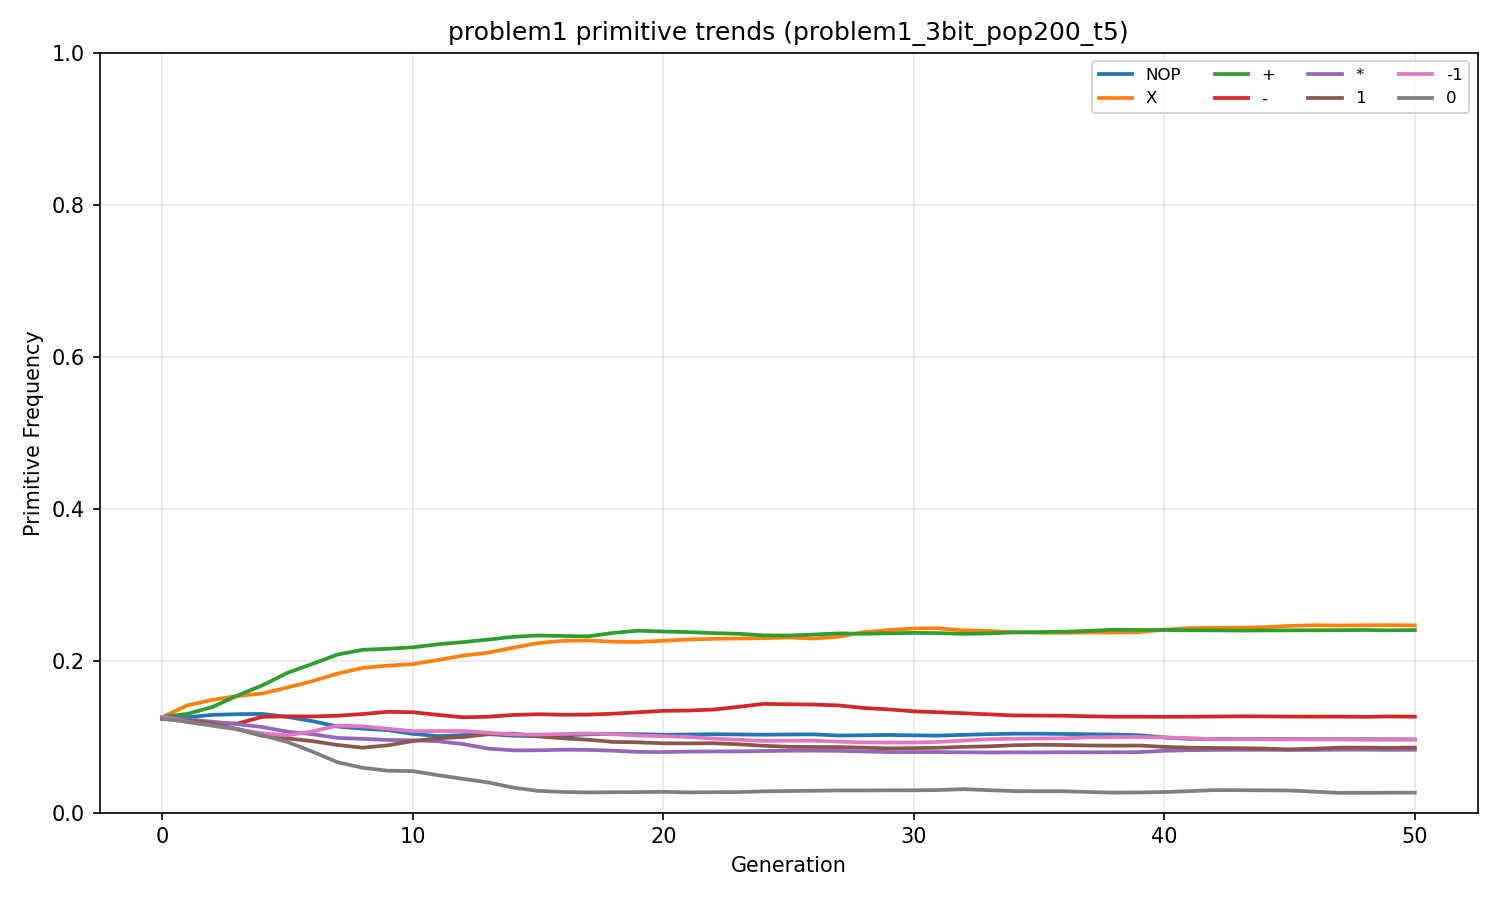

problem2 -> E:\CE310\results\part2\task8_primitives\problem2_primitive_trends.png


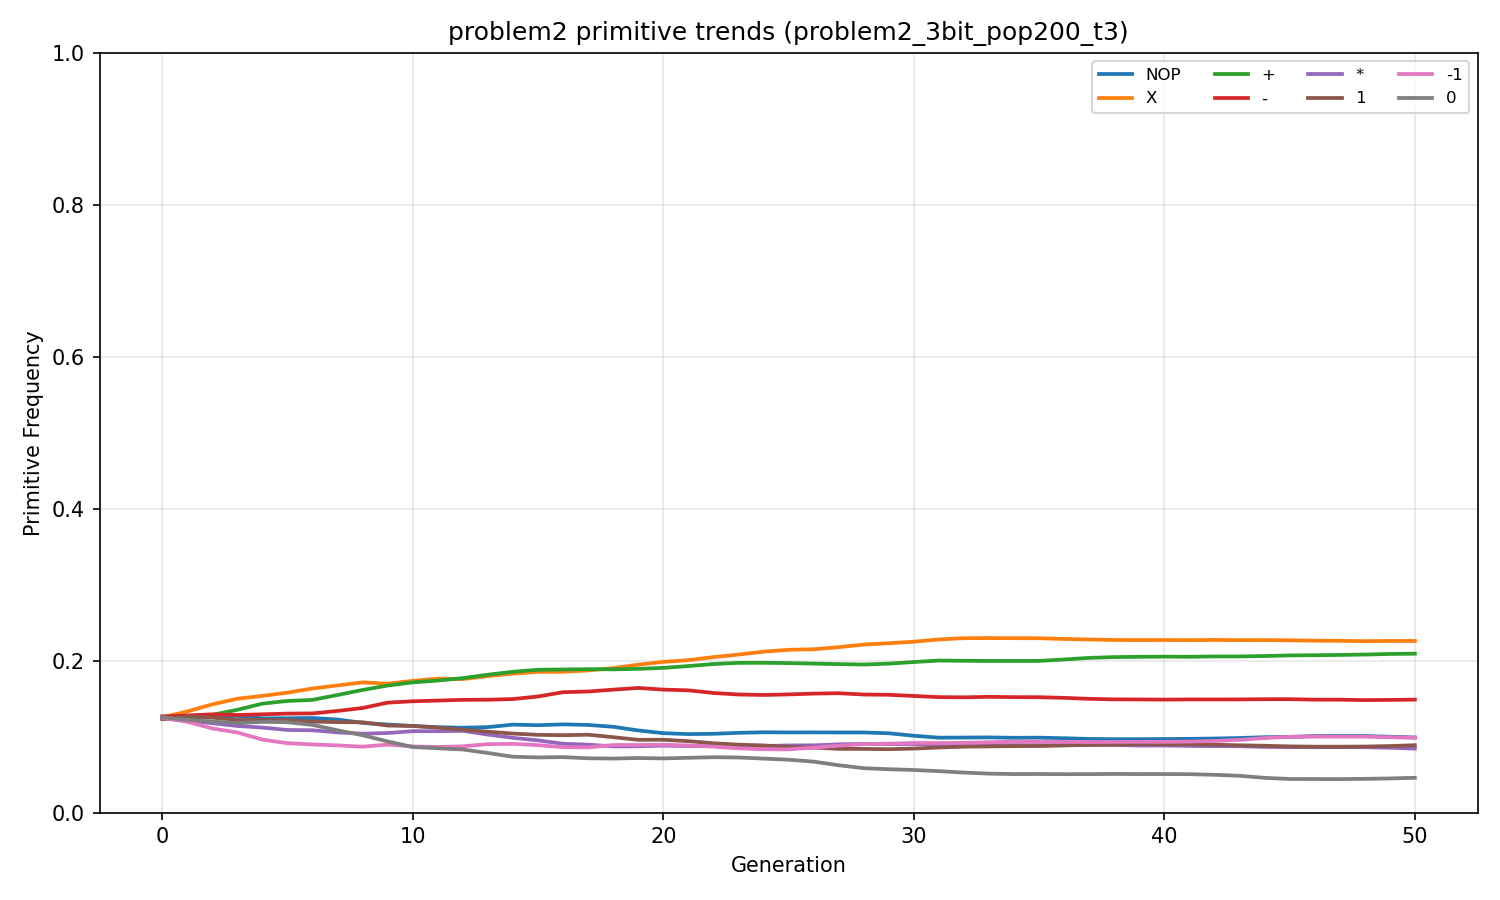

In [18]:
for _, r in task8.iterrows():
    raw = str(r['plot_file'])
    p = Path(raw.replace('\\', '/'))
    if not p.is_absolute():
        p = PROJECT_ROOT / p
    print(r['problem'], '->', p)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print('Missing:', p)

## Task 8 Step 2b - Enhanced Detailed Primitive Evolution (if available)
Display high-resolution prepared trend figures for both problems.

E:\CE310\figures\part2_primitive_evolution_problem1_detailed.png


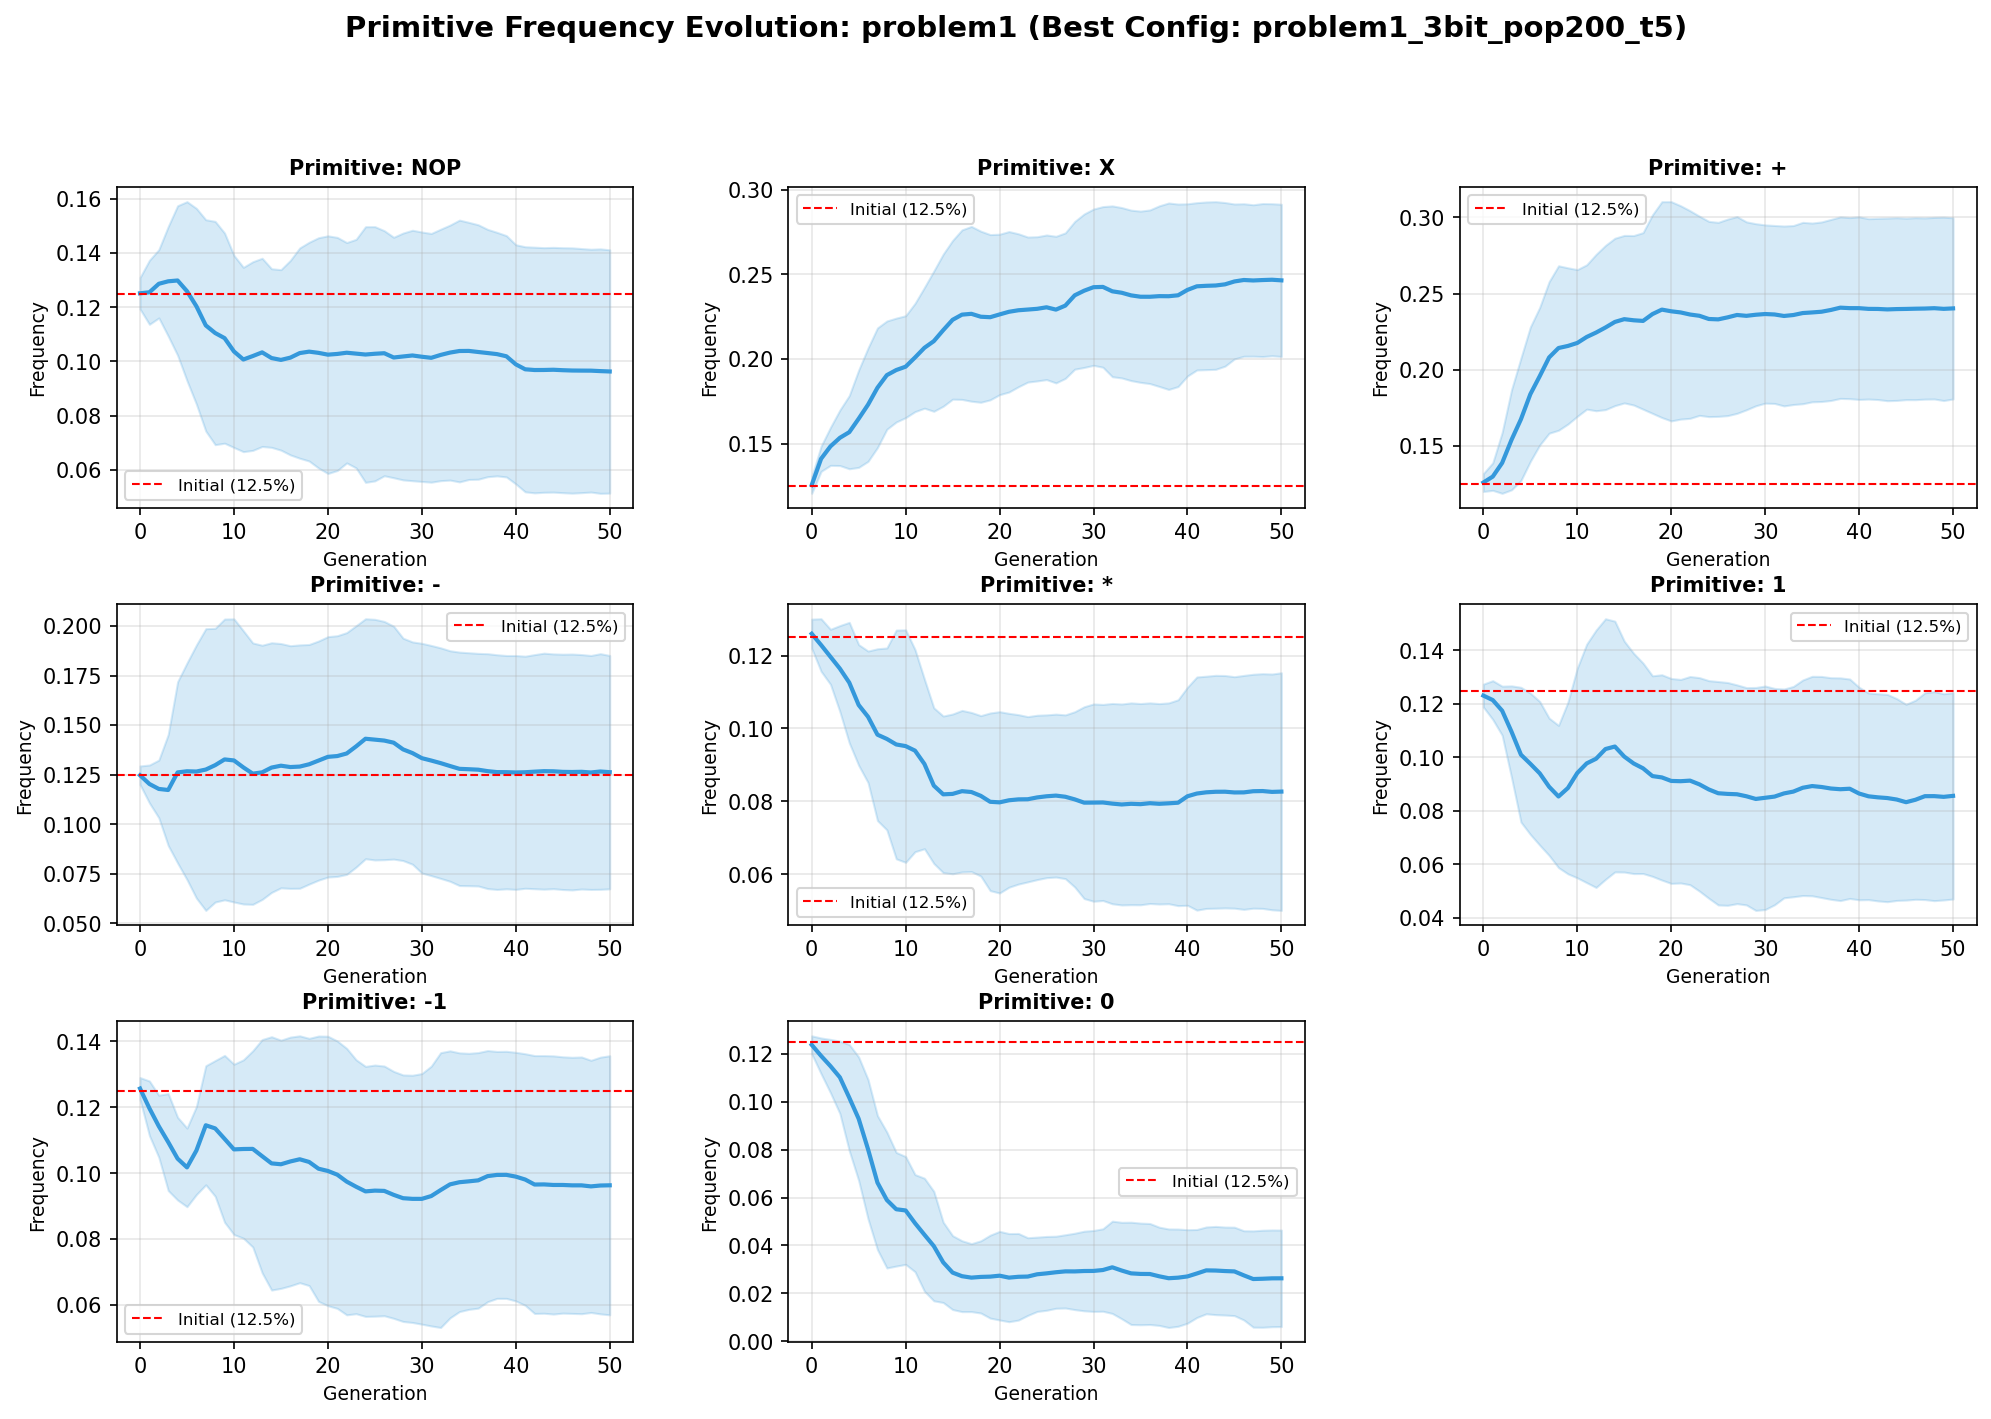

E:\CE310\figures\part2_primitive_evolution_problem2_detailed.png


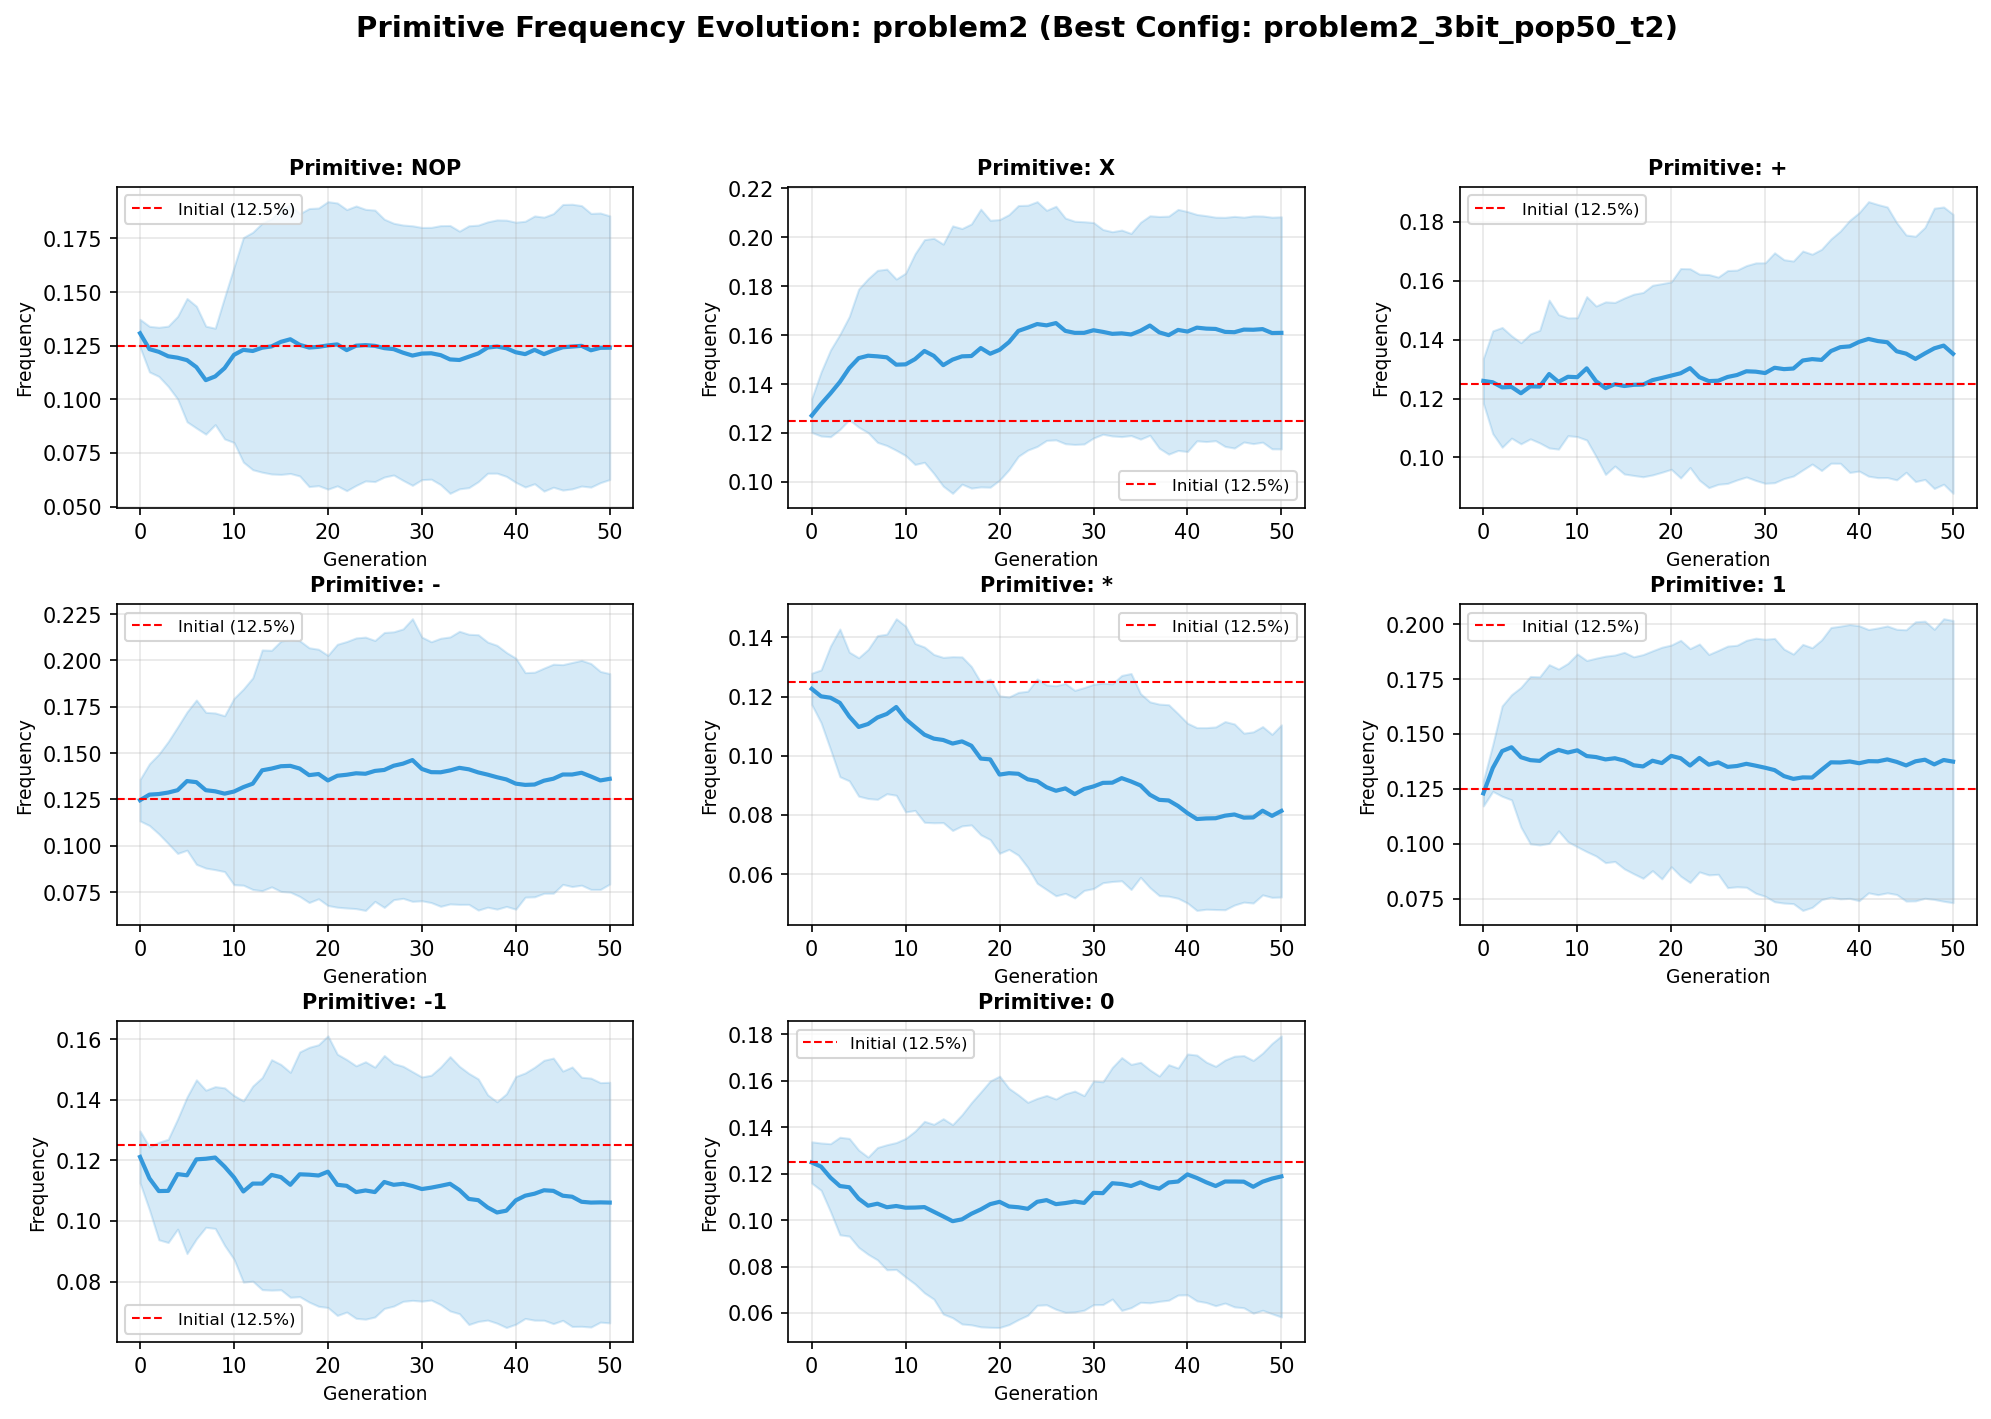

In [19]:
for fn in ['part2_primitive_evolution_problem1_detailed.png','part2_primitive_evolution_problem2_detailed.png']:
    p = FIG / fn
    print(p)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print('Missing figure:', p)

## Task 8 Step 3 - Inspect Aggregated Primitive Frequencies
Read the aggregated primitive-frequency table to connect the chart trends to concrete numeric values.

In [20]:
cond_p2 = str(best_p2['condition'])
agg = pd.read_csv(R2 / 'task7_experiments' / cond_p2 / 'generation_aggregated.csv')
freq_cols = [c for c in agg.columns if c.startswith('freq_') and c.endswith('_mean')]
agg[['generation'] + freq_cols].head()

,generation,freq_NOP_mean,freq_X_mean,freq_+_mean,freq_-_mean,freq_*_mean,freq_1_mean,freq_-1_mean,freq_0_mean
0,0,0.126417,0.125367,0.124517,0.126500,0.123783,0.123050,0.124933,0.125433
1,1,0.125267,0.133133,0.124117,0.127883,0.121300,0.126567,0.119567,0.122167
2,2,0.126200,0.142500,0.128683,0.129300,0.117683,0.125000,0.110733,0.119900
3,3,0.127300,0.149850,0.135367,0.128467,0.114017,0.121917,0.105433,0.117650
4,4,0.124083,0.153683,0.143433,0.129400,0.111917,0.121983,0.096017,0.119483


## Part 2 Final Summary
Print concise report summary for Task5-8.

In [21]:
report_p2 = (R2 / 'part2_report_summary.md').read_text(encoding='utf-8')
print(report_p2[:2500])

# CE310 Part 2 Auto Summary

## Selected GA Baseline from Part 1
- pop_size=300
- tournament_size=2

## Task 5 Encoding Comparison
- `3bit_problem1`: mean best-of-run=32.000, std=11.576
- `7bit_problem1`: mean best-of-run=42.400, std=15.060
- `3bit_problem2`: mean best-of-run=-70.369, std=14.567
- `7bit_problem2`: mean best-of-run=-64.795, std=30.703

## Task 7 Experiments
- Summary file: `results/part2/task7_experiments/task7_summary.csv`
- `problem1_3bit_pop50_t2`: mean best-of-run=14.200, std=9.682, avg_execute_calls/gen=60.7, nominal_execute_calls/gen=100.0, call_reduction=39.3%
- `problem1_3bit_pop50_t3`: mean best-of-run=13.400, std=3.893, avg_execute_calls/gen=45.1, nominal_execute_calls/gen=100.0, call_reduction=54.9%
- `problem1_3bit_pop50_t5`: mean best-of-run=12.400, std=6.915, avg_execute_calls/gen=40.4, nominal_execute_calls/gen=100.0, call_reduction=59.6%
- `problem1_3bit_pop100_t2`: mean best-of-run=14.200, std=6.893, avg_execute_calls/gen=145.2, nominal_execute_calls/ge

## Theory Link (EC/GP)
- Population size and tournament size jointly affect exploration/exploitation balance.
- Run-to-run variability is expected in stochastic evolutionary search.
- Primitive frequencies drift away from uniform initialization as useful building blocks spread through selection.

## Lecture-Alignment Note
This section maps each major design choice to Lecture 1-7 and separates algorithmic choices from implementation details.

## Problem2 Difficulty Explanation
Explain why Problem2 does not reach ideal=0 under the current budget, with reproducible evidence.